In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Task 1

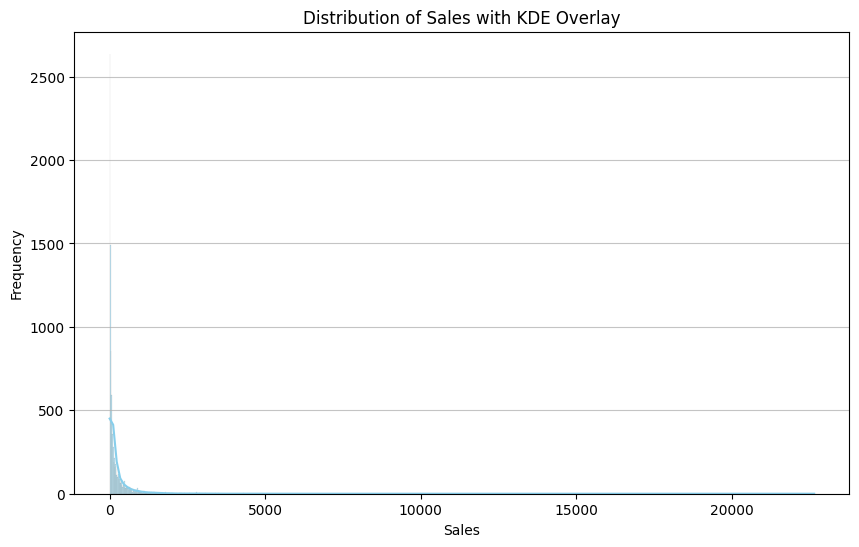

Skewness of Sales: 12.97
Mean of Sales: 229.86
Median of Sales: 54.49

The distribution of Sales is right-skewed. This implies that the mean is pulled towards the higher values and the median might be a more representative measure of central tendency.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram with KDE overlay
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True, color='skyblue')
plt.title('Distribution of Sales with KDE Overlay')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Calculate skewness
skewness_value = df['Sales'].skew()
print(f"Skewness of Sales: {skewness_value:.2f}")

# Compare mean vs. median
mean_sales = df['Sales'].mean()
median_sales = df['Sales'].median()
print(f"Mean of Sales: {mean_sales:.2f}")
print(f"Median of Sales: {median_sales:.2f}")



The mean is pulled towards the higher values and the median might be a more representative measure of central tendency.

# Task 2

/tmp/ipykernel_5049/1840816499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


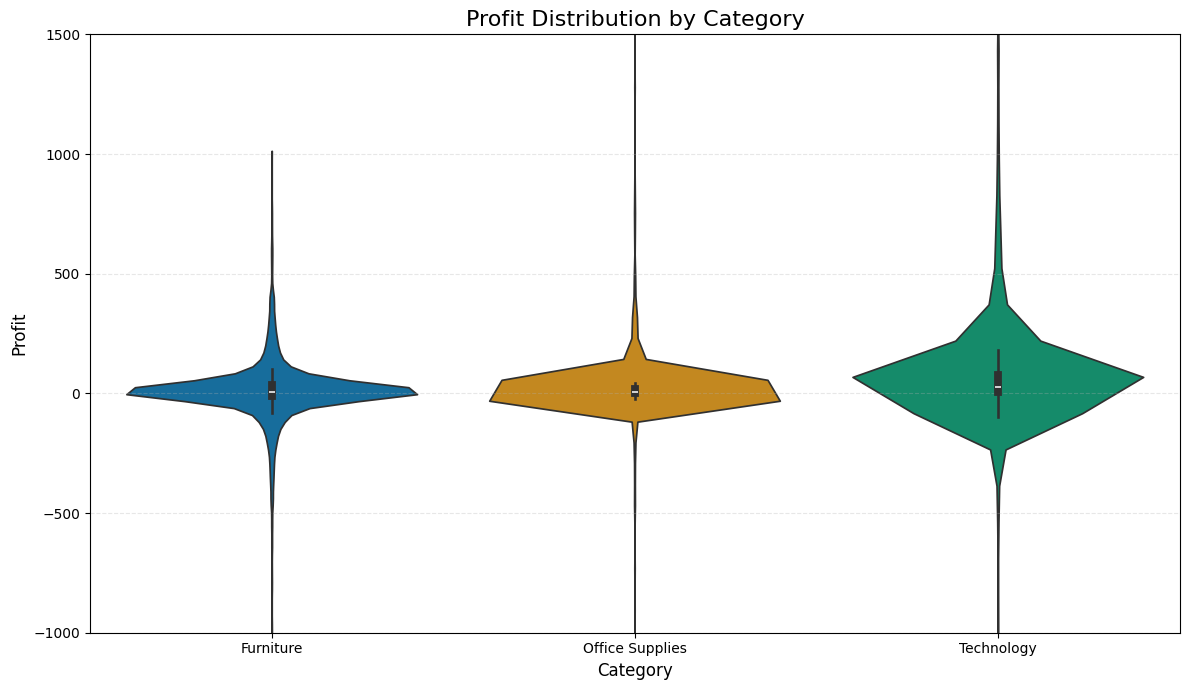

/tmp/ipykernel_5049/1840816499.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Category', y='Profit', data=df, jitter=0.2, alpha=0.6, palette='colorblind')


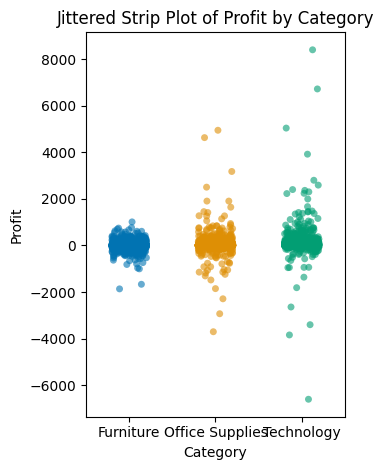

In [23]:
plt.figure(figsize=(12, 7))

sns.violinplot(x='Category',y='Profit',data=df,palette='colorblind',inner='box',cut=0)
plt.ylim(-1000, 1500)
plt.title('Profit Distribution by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Create a Jittered Strip Plot
plt.subplot(1, 2, 2)
sns.stripplot(x='Category', y='Profit', data=df, jitter=0.2, alpha=0.6, palette='colorblind')
plt.title('Jittered Strip Plot of Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()



# Task 3

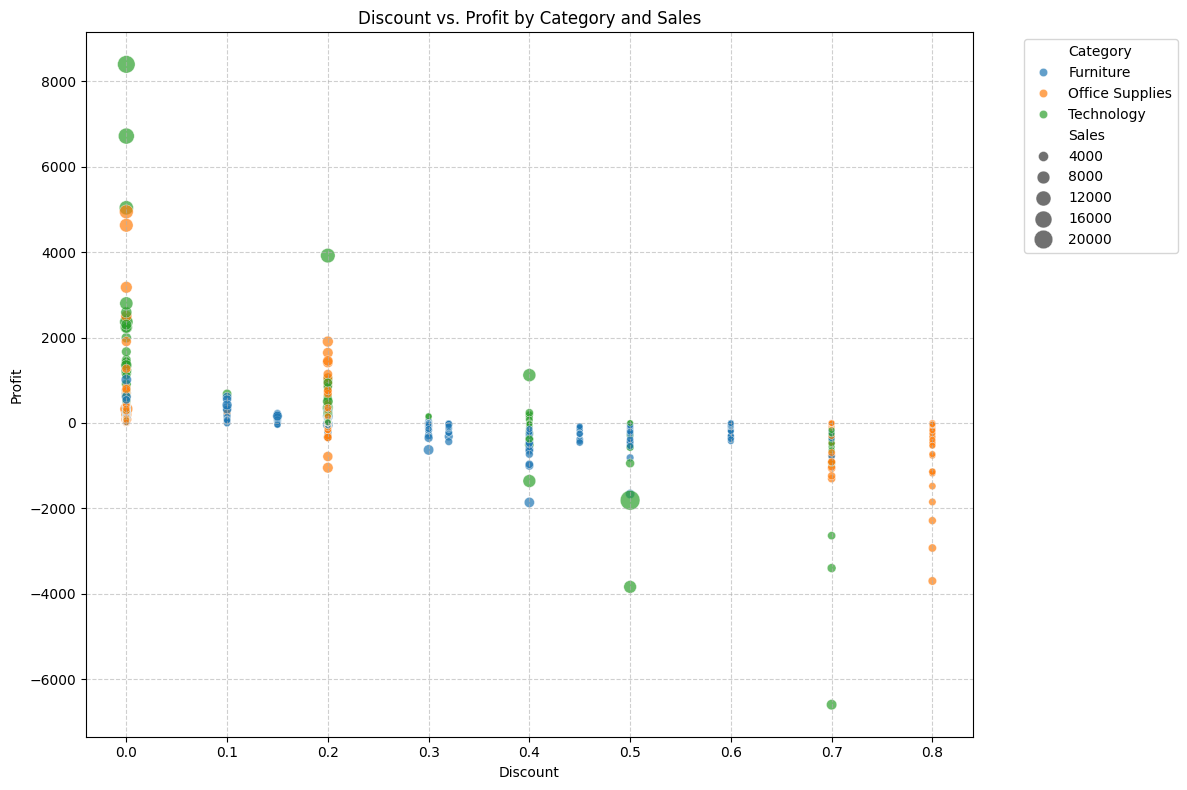

In [24]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Sales', sizes=(20, 200), alpha=0.7)
plt.title('Discount vs. Profit by Category and Sales')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Task 4

Pearson Correlation Matrix:
                Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.009671 -0.001359 -0.004016  0.013480  0.012497
Postal Code  0.009671     1.000000 -0.023854  0.012761  0.058443 -0.029961
Sales       -0.001359    -0.023854  1.000000  0.200795 -0.028190  0.479064
Quantity    -0.004016     0.012761  0.200795  1.000000  0.008623  0.066253
Discount     0.013480     0.058443 -0.028190  0.008623  1.000000 -0.219487
Profit       0.012497    -0.029961  0.479064  0.066253 -0.219487  1.000000

Spearman Correlation Matrix:
                Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.011466 -0.001310 -0.002416  0.012655 -0.010545
Postal Code  0.011466     1.000000 -0.002059  0.013952  0.052793 -0.005451
Sales       -0.001310    -0.002059  1.000000  0.327426 -0.056969  0.518407
Quantity    -0.002416     0.013952  0.327426  1.000000 -0.000878  0.234491
Discount     0.012655     0.052793 -0.05

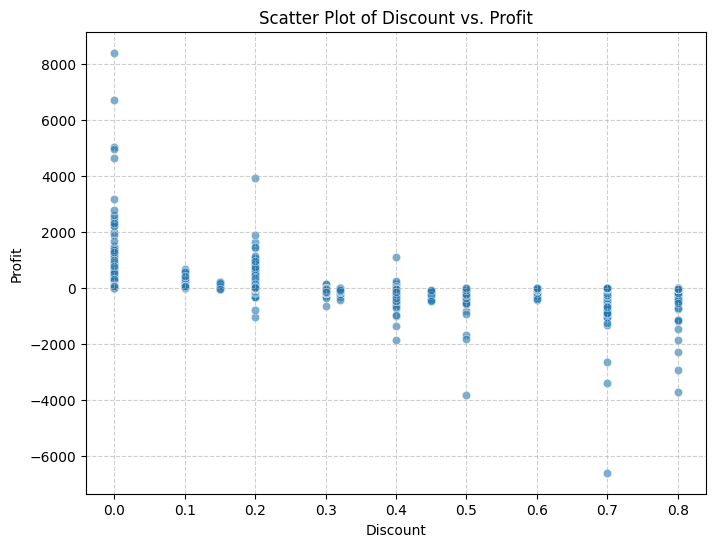

In [11]:
numeric_df = df.select_dtypes(include=['number'])

# Compute Pearson correlation matrix
pearson_corr = numeric_df.corr(method='pearson')
print("Pearson Correlation Matrix:\n", pearson_corr)

# Compute Spearman correlation matrix
spearman_corr = numeric_df.corr(method='spearman')
print("\nSpearman Correlation Matrix:\n", spearman_corr)

diff_matrix = abs(pearson_corr - spearman_corr)

# Exclude self-correlations (diagonal) and find the maximum difference
np.fill_diagonal(diff_matrix.values, 0)
max_diff_idx = diff_matrix.stack().idxmax()
var1, var2 = max_diff_idx

pearson_val = pearson_corr.loc[var1, var2]
spearman_val = spearman_corr.loc[var1, var2]

print(f"  Pearson correlation: {pearson_val:.2f}")
print(f"  Spearman correlation: {spearman_val:.2f}")

# Inspect their scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=var1, y=var2, alpha=0.6)
plt.title(f'Scatter Plot of {var1} vs. {var2}')
plt.xlabel(var1)
plt.ylabel(var2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Spearman correlation, which measures monotonic relationships is stronger. This often indicates a strong ordered relationship between the variables, but the presence of outliers or a non-linear but consistent trend might be attenuating the Pearson correlation.

Correlation does not imply causation. Even a strong correlation between '{var1}' and '{var2}' does not mean that changes in one directly cause changes in the other. There might be confounding variables or the relationship could be purely coincidental

# Task 5

Region x Category Total Sales Pivot Table:
 Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


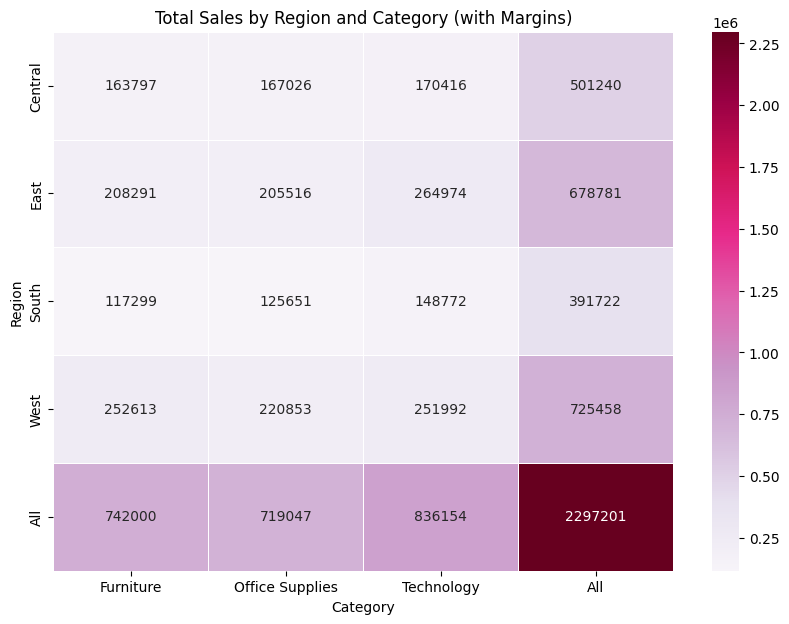

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the pivot table
sales_pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum', margins=True)

print("Region x Category Total Sales Pivot Table:\n", sales_pivot)

# Render as a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(sales_pivot, annot=True, fmt=".0f", cmap="PuRd", linewidths=.5)
plt.title('Total Sales by Region and Category (with Margins)')
plt.ylabel('Region')
plt.xlabel('Category')
plt.show()


max_sales_combination = sales_pivot.drop(columns=['All'], index=['All']).stack().idxmax()
max_sales_value = sales_pivot.drop(columns=['All'], index=['All']).stack().max()


# Task 6

/tmp/ipykernel_5049/3948769688.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('Order Date')['Sales'].resample('M').sum()


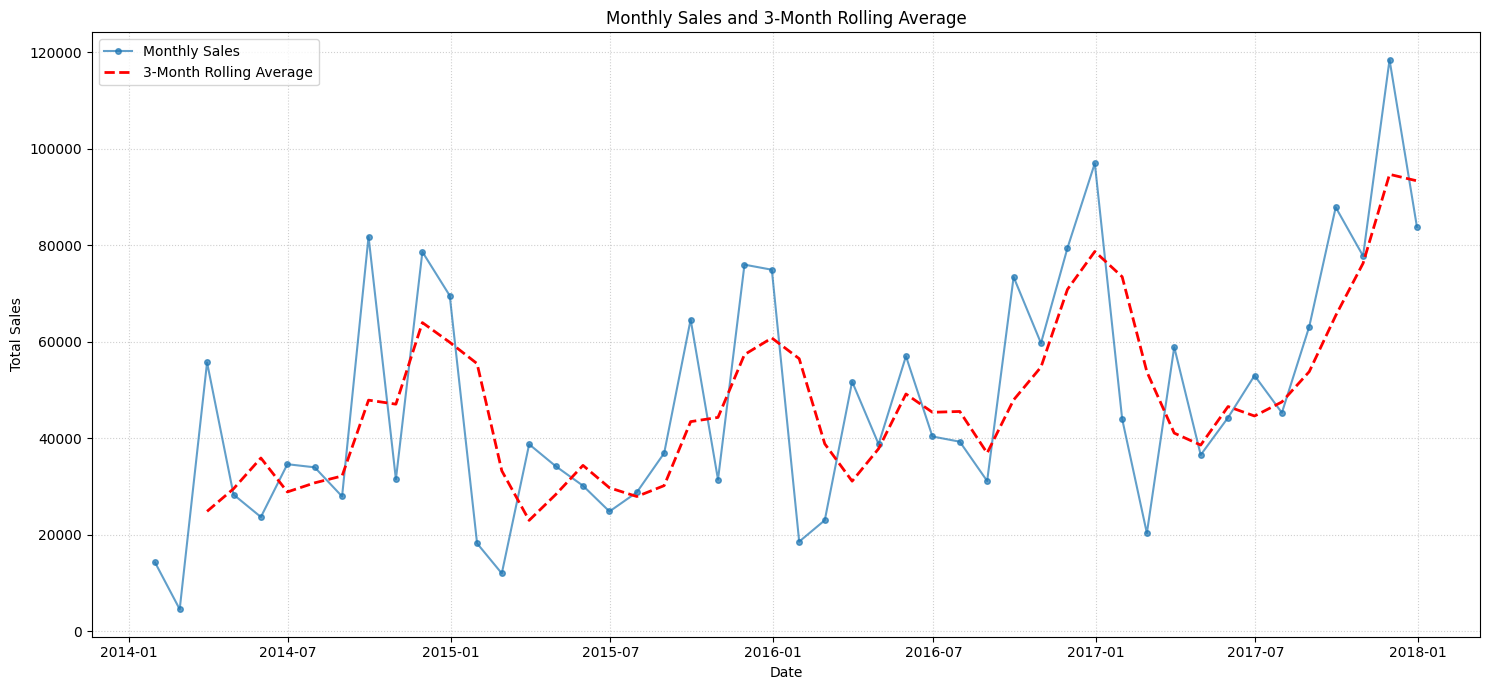

In [15]:

df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.set_index('Order Date')['Sales'].resample('M').sum()

# Calculate a 3-month rolling average
rolling_avg_sales = monthly_sales.rolling(window=3).mean()

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(monthly_sales.index, monthly_sales.values, label='Monthly Sales', marker='o', linestyle='-', markersize=4, alpha=0.7)
plt.plot(rolling_avg_sales.index, rolling_avg_sales.values, label='3-Month Rolling Average', color='red', linestyle='--', linewidth=2)
plt.title('Monthly Sales and 3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

This helps in identifying whether sales are generally increasing, decreasing, or remaining stable over a longer period

# Task 7

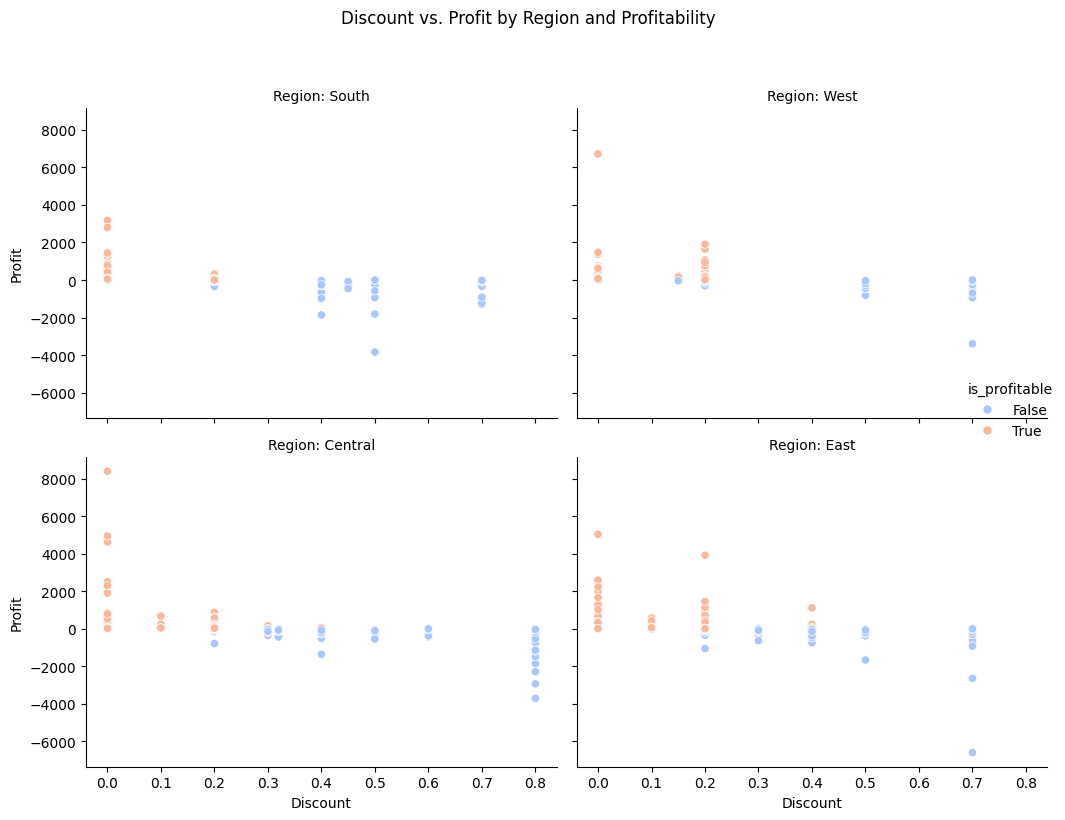

In [19]:
df['is_profitable'] = df['Profit'] > 0

g = sns.relplot(data=df, x='Discount', y='Profit', col='Region', hue='is_profitable',
                kind='scatter', height=4, aspect=1.2, col_wrap=2, palette='coolwarm')
g.set_axis_labels('Discount', 'Profit')
g.set_titles('Region: {col_name}')
g.add_legend()
plt.suptitle('Discount vs. Profit by Region and Profitability', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# Task 8

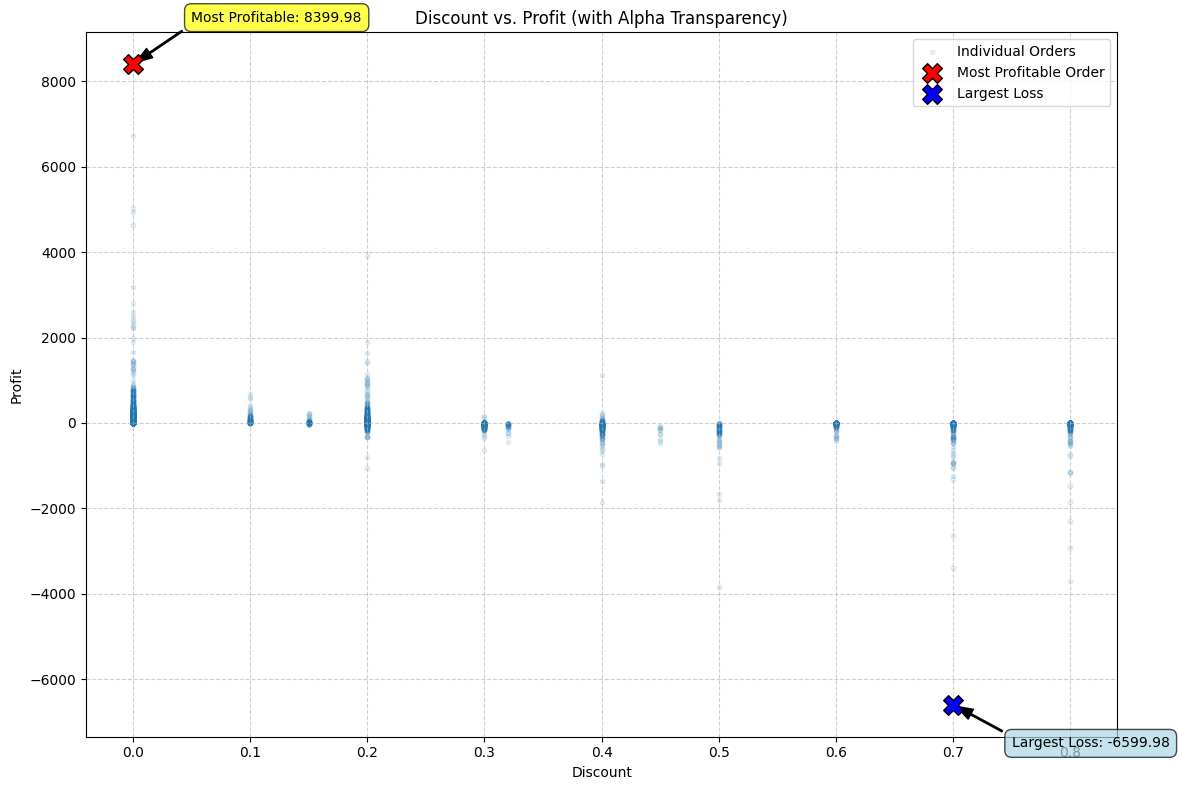

In [21]:
# Find the most profitable order and the largest loss (re-use from previous cell)
most_profitable_order = df.loc[df['Profit'].idxmax()]
largest_loss_order = df.loc[df['Profit'].idxmin()]

plt.figure(figsize=(12, 8))

# Use alpha transparency to address overplotting
plt.scatter(df['Discount'], df['Profit'], alpha=0.1, s=10, label='Individual Orders')
plt.title('Discount vs. Profit (with Alpha Transparency)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the most profitable order
plt.scatter(most_profitable_order['Discount'], most_profitable_order['Profit'],
            color='red', marker='X', s=200, edgecolor='black', zorder=5, label='Most Profitable Order')
plt.annotate(f"Most Profitable: {most_profitable_order['Profit']:.2f}",
             xy=(most_profitable_order['Discount'], most_profitable_order['Profit']),
             xytext=(most_profitable_order['Discount'] + 0.05, most_profitable_order['Profit'] + 1000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7), fontsize=10)

# Annotate the largest loss
plt.scatter(largest_loss_order['Discount'], largest_loss_order['Profit'],
            color='blue', marker='X', s=200, edgecolor='black', zorder=5, label='Largest Loss')
plt.annotate(f"Largest Loss: {largest_loss_order['Profit']:.2f}",
             xy=(largest_loss_order['Discount'], largest_loss_order['Profit']),
             xytext=(largest_loss_order['Discount'] + 0.05, largest_loss_order['Profit'] - 1000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7), fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

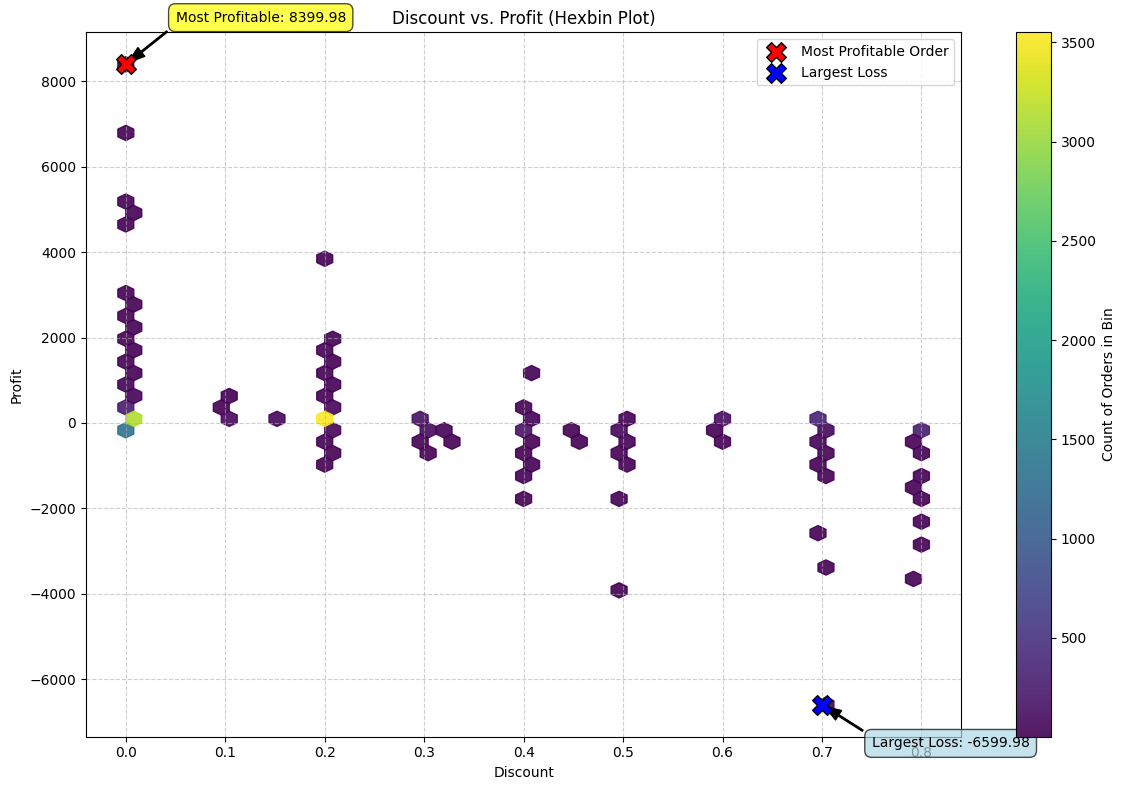

In [22]:
most_profitable_order = df.loc[df['Profit'].idxmax()]
largest_loss_order = df.loc[df['Profit'].idxmin()]

plt.figure(figsize=(12, 8))

# Use hexbin to address overplotting, as it's better for high point counts to show density patterns.
plt.hexbin(df['Discount'], df['Profit'], gridsize=50, cmap='viridis', mincnt=1, alpha=0.9)
plt.colorbar(label='Count of Orders in Bin')
plt.title('Discount vs. Profit (Hexbin Plot)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the most profitable order
plt.scatter(most_profitable_order['Discount'], most_profitable_order['Profit'],
            color='red', marker='X', s=200, edgecolor='black', zorder=5, label='Most Profitable Order')
plt.annotate(f"Most Profitable: {most_profitable_order['Profit']:.2f}",
             xy=(most_profitable_order['Discount'], most_profitable_order['Profit']),
             xytext=(most_profitable_order['Discount'] + 0.05, most_profitable_order['Profit'] + 1000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7), fontsize=10)

# Annotate the largest loss
plt.scatter(largest_loss_order['Discount'], largest_loss_order['Profit'],
            color='blue', marker='X', s=200, edgecolor='black', zorder=5, label='Largest Loss')
plt.annotate(f"Largest Loss: {largest_loss_order['Profit']:.2f}",
             xy=(largest_loss_order['Discount'], largest_loss_order['Profit']),
             xytext=(largest_loss_order['Discount'] + 0.05, largest_loss_order['Profit'] - 1000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7), fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()